# U-Phase: Verkehrsprognose - Die Daten verstehen

<div style="padding:14px 16px;border-radius:12px;background:linear-gradient(135deg,#0f172a,#1e293b);color:#e2e8f0;margin:8px 0 6px 0;">
  <b>Phase U (Understanding)</b><br>
  Fokus dieser Version: reale Open-Traffic-Daten der Stadt Darmstadt aus 2025, inklusive OSM-Karte für das Stadtgebiet und einer sauberen Übergabe an die A-Phase.
</div>

## Ziel dieser Phase

In der U-Phase schaffen wir Transparenz für Fachseite und Management:
- Welche reale Datengrundlage steht für Darmstadt zur Verfügung?
- Wie vollständig und konsistent sind die Rohdaten?
- Welche Intraday-, Wochen- und Monatsmuster zeigt das Verkehrsaufkommen?
- Welche Features exportieren wir für die Modellphase?

Am Ende steht ein sauberer Datensatz unter `data/df_final.csv`, der direkt in der A-Phase weiterverwendet wird.

## Datensatzwahl für die Verkehrsprognose

### Primäre Datenquelle

**Darmstadt Open Traffic Data 2025**
- Im Projekt abgelegt unter `data/Open Traffic Data/`
- 1-Minuten-Rohdaten je Anlage (ZIP-Dateien `A001` bis `A050`)
- Verdichtung in diesem Notebook auf Stundenwerte für Forecasting und Management-Analysen
- Vorteil: echte kommunale Messdaten mit sehr hoher zeitlicher Auflösung
- Besonderheit: für die Kartenansicht kombinieren wir die Messwerte mit OSM-Straßengeometrien für Darmstadt

In [1]:
import subprocess
import sys
import zipfile
from io import BytesIO
from pathlib import Path

repo_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
requirements_path = repo_root / 'requirements.txt'

try:
    import folium
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-r', str(requirements_path)])
    import folium

from IPython.display import HTML, display

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use('ggplot')
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=plt.cm.tab10.colors)
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12

src_path = repo_root / 'src'
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from traffic_app.config import CITY_CONFIG_DIR
from traffic_app.data import ensure_city_street_schema, load_city_street_reference, read_open_traffic_zip_bytes
from traffic_app.mapping import build_street_map_data

print('Werkzeuge für Darmstadt-EDA und OSM-Karte geladen.')


2026-03-31 19:28:05.351 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-03-31 19:28:05.355 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager


Werkzeuge für Darmstadt-EDA und OSM-Karte geladen.


## Schritt 1: Open-Traffic-Datenquellen prüfen

Zuerst verschaffen wir uns einen Überblick über die im Projekt vorhandenen Darmstadt-Archive und ihre Messkanalanzahl.

In [2]:
open_traffic_dir = repo_root / 'data' / 'Open Traffic Data'
archive_rows = []

for zip_path in sorted(open_traffic_dir.glob('*.zip')):
    with zipfile.ZipFile(zip_path) as archive:
        csv_members = [name for name in archive.namelist() if name.lower().endswith('.csv')]
        if not csv_members:
            archive_rows.append({
                'anlage': zip_path.stem.split('_')[0],
                'zip_datei': zip_path.name,
                'monate': 0,
                'messkanäle': 0,
            })
            continue

        with archive.open(csv_members[0]) as handle:
            header = pd.read_csv(handle, sep=';', nrows=0)

        count_cols = [column for column in header.columns if '(Belegungen/Intervall)' in str(column)]
        archive_rows.append({
            'anlage': zip_path.stem.split('_')[0],
            'zip_datei': zip_path.name,
            'monate': len(csv_members),
            'messkanäle': len(count_cols),
        })

archive_overview = pd.DataFrame(archive_rows).sort_values('anlage').reset_index(drop=True)
print('Archive gefunden:', len(archive_overview))
print('Anlagen mit Messdaten:', int((archive_overview['monate'] > 0).sum()))
print('Messkanäle gesamt:', int(archive_overview['messkanäle'].sum()))
display(archive_overview.head(10))

Archive gefunden: 50
Anlagen mit Messdaten: 48
Messkanäle gesamt: 1249


,anlage,zip_datei,monate,messkanäle
0,A001,A001_2.zip,12,25
1,A002,A002_2.zip,0,0
2,A003,A003_3.zip,12,31
3,A004,A004_3.zip,12,49
4,A005,A005_3.zip,12,34
5,A006,A006_3.zip,12,26
6,A007,A007_3.zip,12,15
7,A008,A008_3.zip,12,54
8,A009,A009_3.zip,12,17
9,A010,A010_3.zip,12,16


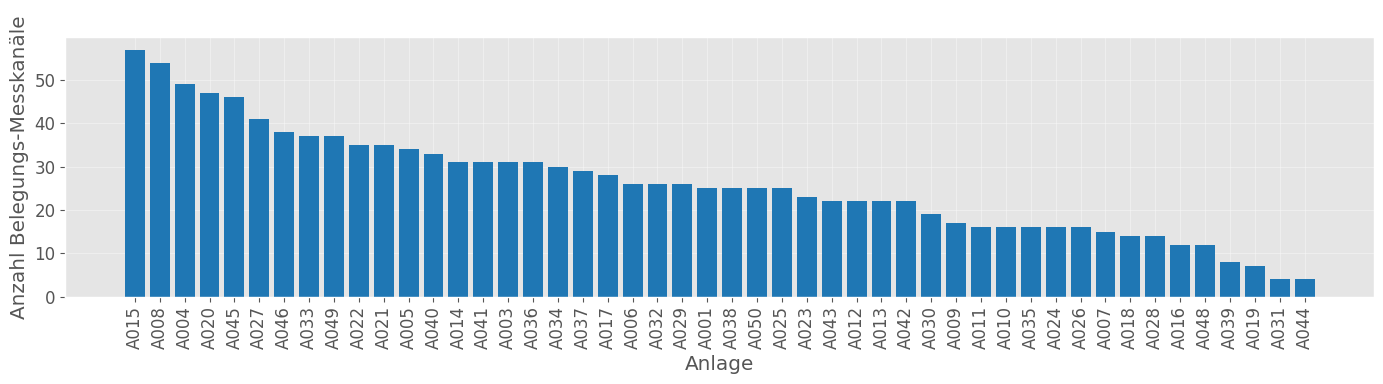

In [3]:
plt.figure(figsize=(14, 4))
archive_plot = archive_overview[archive_overview['monate'] > 0].copy()
archive_plot = archive_plot.sort_values('messkanäle', ascending=False)
plt.bar(archive_plot['anlage'], archive_plot['messkanäle'])
plt.title('Messkanäle pro Darmstadt-Anlage')
plt.xlabel('Anlage')
plt.ylabel('Anzahl Belegungs-Messkanäle')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


### Kundeninterpretation

Die Datengrundlage basiert nicht auf Demo- oder Zufallswerten, sondern auf echten kommunalen Rohmessungen. Für die Fachseite ist damit nachvollziehbar, aus wie vielen Anlagen und Messkanälen die Stundenserie gebildet wird.

## Schritt 2: Darmstadt-Stundenserie aus allen Open-Traffic-Archiven erzeugen

Die U-Phase verwendet direkt alle ZIP-Dateien unter data/Open Traffic Data/. Zunächst lesen wir jede Anlage als stundenweise Sensorspur ein und verdichten sie anschließend zu einer eindeutigen Stadt-Stundenserie für die Analyse.


In [4]:
open_traffic_dir = repo_root / 'data' / 'Open Traffic Data'
archive_frames = []
archive_import_rows = []

for zip_path in sorted(open_traffic_dir.glob('*.zip')):
    with zipfile.ZipFile(zip_path) as archive:
        csv_members = [name for name in archive.namelist() if name.lower().endswith('.csv')]
        if not csv_members:
            archive_import_rows.append({'zip_datei': zip_path.name, 'monate': 0, 'stundenwerte': 0, 'status': 'keine csv'})
            continue

        monthly_frames = []
        parse_warnings = 0
        for member in sorted(csv_members):
            raw_bytes = archive.read(member)
            month_df = None
            for encoding in ('utf-8-sig', 'utf-8', 'latin-1'):
                try:
                    month_df = pd.read_csv(BytesIO(raw_bytes), sep=';', encoding=encoding, low_memory=False)
                    break
                except Exception:
                    try:
                        month_df = pd.read_csv(BytesIO(raw_bytes), sep=';', encoding=encoding, engine='python')
                        break
                    except Exception:
                        try:
                            month_df = pd.read_csv(BytesIO(raw_bytes), sep=';', encoding=encoding, engine='python', on_bad_lines='skip')
                            parse_warnings += 1
                            break
                        except Exception:
                            month_df = None
            if month_df is None or month_df.empty:
                continue

            month_df.columns = [str(column).strip() for column in month_df.columns]
            timestamp_col = 'Intervallbeginn (Lokalzeit)' if 'Intervallbeginn (Lokalzeit)' in month_df.columns else 'Intervallbeginn (UTC)'
            if timestamp_col not in month_df.columns:
                continue

            count_cols = [column for column in month_df.columns if '(Belegungen/Intervall)' in str(column)]
            if not count_cols:
                continue

            timestamps = pd.to_datetime(month_df[timestamp_col], errors='coerce', dayfirst=True)
            total_flow = month_df[count_cols].apply(pd.to_numeric, errors='coerce').sum(axis=1, min_count=1)
            month_hourly = pd.DataFrame({'ds': timestamps, 'y': total_flow}).dropna(subset=['ds', 'y'])
            if month_hourly.empty:
                continue

            month_hourly['ds'] = month_hourly['ds'].dt.floor('h')
            month_hourly = month_hourly.groupby('ds', as_index=False)['y'].sum()
            month_hourly['source_zip'] = zip_path.name
            month_hourly['dataset'] = zip_path.stem.split('_')[0]
            monthly_frames.append(month_hourly)

        if not monthly_frames:
            archive_import_rows.append({'zip_datei': zip_path.name, 'monate': len(csv_members), 'stundenwerte': 0, 'status': 'keine Messwerte'})
            continue

        archive_df = pd.concat(monthly_frames, ignore_index=True)
        archive_frames.append(archive_df)
        status = 'ok' if parse_warnings == 0 else f'ok ({parse_warnings} Parser-Fallbacks)'
        archive_import_rows.append({'zip_datei': zip_path.name, 'monate': len(csv_members), 'stundenwerte': len(archive_df), 'status': status})

if not archive_frames:
    raise ValueError('Es konnten keine verwendbaren Open-Traffic-Daten aus den ZIP-Dateien gelesen werden.')

raw_traffic_df = pd.concat(archive_frames, ignore_index=True)
raw_traffic_df['ds'] = pd.to_datetime(raw_traffic_df['ds'], errors='coerce')
raw_traffic_df['y'] = pd.to_numeric(raw_traffic_df['y'], errors='coerce')
raw_traffic_df = raw_traffic_df.dropna(subset=['ds', 'y'])
raw_traffic_df = raw_traffic_df[(raw_traffic_df['ds'] >= pd.Timestamp('2025-01-01')) & (raw_traffic_df['ds'] < pd.Timestamp('2026-01-01'))]
raw_traffic_df = raw_traffic_df.sort_values(['ds', 'source_zip']).reset_index(drop=True)

df = raw_traffic_df.groupby('ds', as_index=False).agg(
    y=('y', 'sum'),
    active_anlagen=('dataset', 'nunique'),
    source_zips=('source_zip', 'nunique'),
)
df['city'] = 'Darmstadt'
df['weather'] = 'unknown'
df = df.sort_values('ds').reset_index(drop=True)
df['hour'] = df['ds'].dt.hour
df['weekday'] = df['ds'].dt.dayofweek
df['month'] = df['ds'].dt.month

archive_import_overview = pd.DataFrame(archive_import_rows)
display(df.head())
print('Verwendete ZIP-Dateien:', int(archive_import_overview['status'].astype(str).str.startswith('ok').sum()))
print('Anlagen-Stundenwerte:', len(raw_traffic_df))
print('Aggregierte Stadtstunden:', len(df))
print('Zeitraum:', df['ds'].min(), 'bis', df['ds'].max())
display(archive_import_overview.head(10))


,ds,y,active_anlagen,source_zips,city,weather,hour,weekday,month
0,2025-01-01 00:00:00,34566.0,45,45,Darmstadt,unknown,0,2,1
1,2025-01-01 01:00:00,50979.0,45,45,Darmstadt,unknown,1,2,1
2,2025-01-01 02:00:00,45016.0,45,45,Darmstadt,unknown,2,2,1
3,2025-01-01 03:00:00,32939.0,45,45,Darmstadt,unknown,3,2,1
4,2025-01-01 04:00:00,23765.0,45,45,Darmstadt,unknown,4,2,1


Verwendete ZIP-Dateien: 48
Anlagen-Stundenwerte: 398591
Aggregierte Stadtstunden: 8758
Zeitraum: 2025-01-01 00:00:00 bis 2025-12-31 23:00:00


,zip_datei,monate,stundenwerte,status
0,A001_2.zip,12,7954,ok (1 Parser-Fallbacks)
1,A002_2.zip,0,0,keine csv
2,A003_3.zip,12,8754,ok
3,A004_3.zip,12,8758,ok
4,A005_3.zip,12,8680,ok (1 Parser-Fallbacks)
5,A006_3.zip,12,8758,ok
6,A007_3.zip,12,8740,ok (1 Parser-Fallbacks)
7,A008_3.zip,12,8712,ok (1 Parser-Fallbacks)
8,A009_3.zip,12,8758,ok
9,A010_3.zip,12,8758,ok


## 1) Sind die Daten vollständig und korrekt?

Wir prüfen technische Datenqualität, Duplikate und Zeitlücken der Darmstadt-Stundenserie.

In [5]:
expected_hours = pd.date_range(df['ds'].min(), df['ds'].max(), freq='h')
missing_hours = expected_hours.difference(pd.DatetimeIndex(df['ds']))

print('Größe:', df.shape)
print('Duplikate:', int(df.duplicated(subset=['ds']).sum()))
print('Fehlende Werte:')
display(df.isnull().sum())
print('Erwartete Stunden im Zeitraum:', len(expected_hours))
print('Fehlende Stunden:', len(missing_hours))
if len(missing_hours) > 0:
    display(pd.DataFrame({'fehlende_stunde': missing_hours[:10]}))

Größe: (8758, 9)
Duplikate: 0
Fehlende Werte:


ds                0
y                 0
active_anlagen    0
source_zips       0
city              0
weather           0
hour              0
weekday           0
month             0
dtype: int64

Erwartete Stunden im Zeitraum: 8760
Fehlende Stunden: 2


,fehlende_stunde
0,2025-03-30 02:00:00
1,2025-03-30 03:00:00


### Kundeninterpretation

Die Reihe ist für 2025 nahezu lückenlos auf Stundenebene. Genau diese technische Stabilität brauchen wir, bevor wir Prognosemodelle trainieren oder KPIs für die Leitstelle ableiten.

## 2) Wie hoch ist das typische Verkehrsaufkommen?

Wir betrachten die Verteilung der aggregierten Stundenwerte für Darmstadt.

In [6]:
stats = df['y'].describe()
print(stats)

count      8758.000000
mean      82398.840146
std       31988.922137
min        7770.000000
25%       53348.250000
50%       86362.000000
75%      109189.500000
max      154335.000000
Name: y, dtype: float64


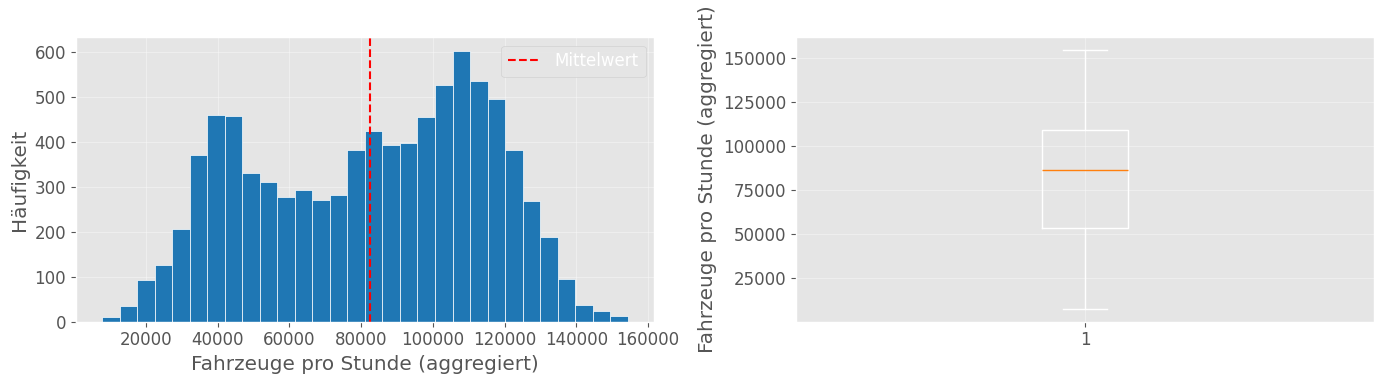

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['y'], bins=30, edgecolor='white')
axes[0].axvline(df['y'].mean(), color='red', linestyle='--', label='Mittelwert')
axes[0].set_title('Histogramm: Verteilung des Verkehrsaufkommens')
axes[0].set_xlabel('Fahrzeuge pro Stunde (aggregiert)')
axes[0].set_ylabel('Häufigkeit')
axes[0].legend()

axes[1].boxplot(df['y'])
axes[1].set_title('Boxplot: Streuung und Ausreisser')
axes[1].set_ylabel('Fahrzeuge pro Stunde (aggregiert)')

plt.tight_layout()
plt.show()

## 3) Zeitliche Muster im Darmstadt-Verkehr

Jetzt analysieren wir den Jahresverlauf, den Tagesrhythmus sowie Wochen- und Monatsmuster.

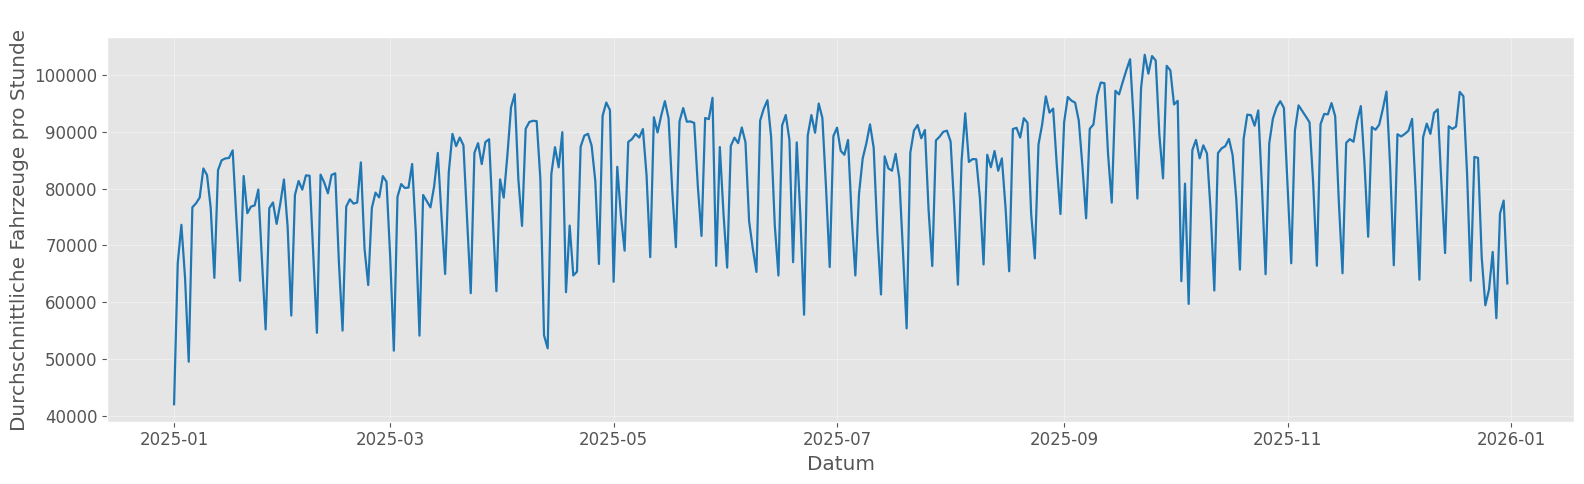

In [8]:
df_daily = df.set_index('ds')['y'].resample('D').mean().reset_index()

plt.figure(figsize=(16, 5))
plt.plot(df_daily['ds'], df_daily['y'], linewidth=1.6)
plt.title('Darmstadt: Tagesdurchschnitt des Verkehrsaufkommens')
plt.xlabel('Datum')
plt.ylabel('Durchschnittliche Fahrzeuge pro Stunde')
plt.tight_layout()
plt.show()


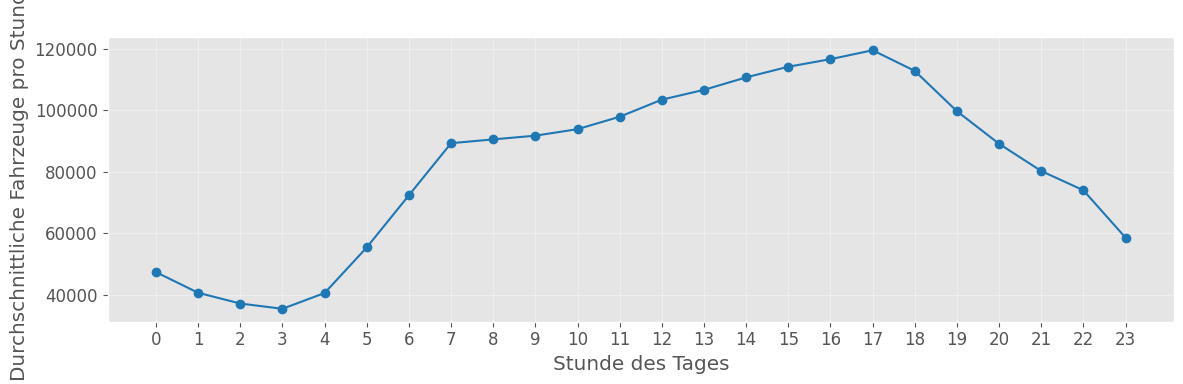

In [9]:
hour_avg = df.groupby('hour')['y'].mean()

plt.figure(figsize=(12, 4))
plt.plot(hour_avg.index, hour_avg.values, marker='o')
plt.title('Darmstadt: Durchschnittlicher Verkehr nach Uhrzeit')
plt.xlabel('Stunde des Tages')
plt.ylabel('Durchschnittliche Fahrzeuge pro Stunde')
plt.xticks(range(24))
plt.tight_layout()
plt.show()

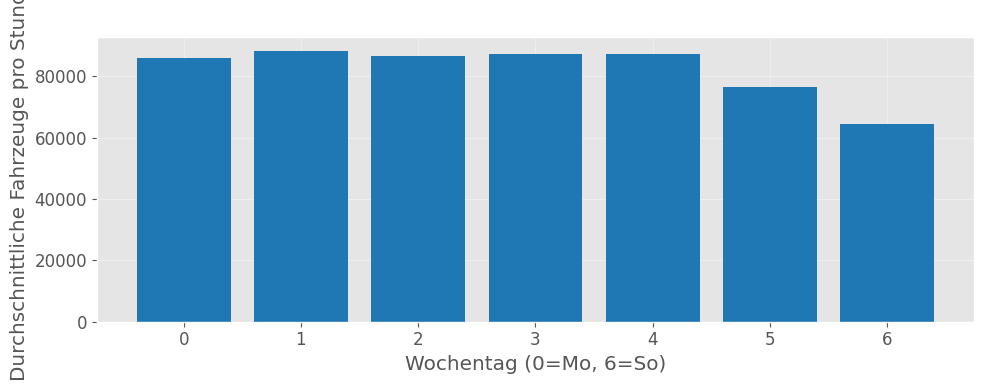

In [10]:
weekday_avg = df.groupby('weekday')['y'].mean()
df['is_weekend'] = (df['weekday'] >= 5).astype(int)

plt.figure(figsize=(10, 4))
plt.bar(range(7), weekday_avg.values)
plt.title('Darmstadt: Durchschnittliches Verkehrsaufkommen pro Wochentag')
plt.xlabel('Wochentag (0=Mo, 6=So)')
plt.ylabel('Durchschnittliche Fahrzeuge pro Stunde')
plt.xticks(range(7))
plt.tight_layout()
plt.show()

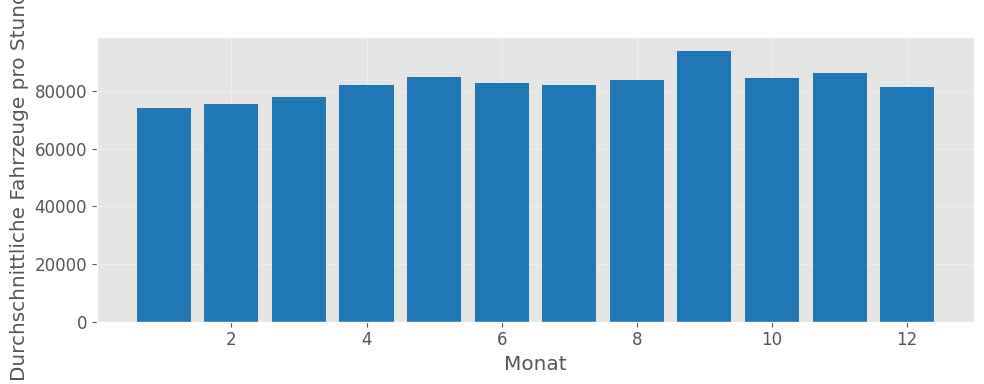

In [11]:
month_avg = df.groupby('month')['y'].mean()

plt.figure(figsize=(10, 4))
plt.bar(month_avg.index, month_avg.values)
plt.title('Darmstadt: Durchschnittliches Verkehrsaufkommen pro Monat')
plt.xlabel('Monat')
plt.ylabel('Durchschnittliche Fahrzeuge pro Stunde')
plt.tight_layout()
plt.show()

### Kundeninterpretation

Die reale Darmstadt-Serie zeigt typische urbane Muster: deutliche Unterschiede zwischen Nacht und Tagesrandlagen, Werktagsdominanz und ein saisonal leicht variierendes Jahresprofil.

## 4) Wetter und fachliche Limitationen

Die Darmstadt-Rohdaten enthalten in den vorliegenden ZIP-Dateien keine eigenen Wetterspalten. Für die Anschlussfähigkeit an die A-Phase behalten wir daher die Kategorie `unknown` als Platzhalter bei.

In [12]:
display(df['weather'].value_counts(dropna=False).rename_axis('weather').reset_index(name='stunden'))

,weather,stunden
0,unknown,8758


## 5) Darmstadt-Karte mit OSM

Für die Kartenansicht kombinieren wir die reale Stadt-Gesamtserie mit Darmstadt-Hauptachsen aus den lokalen Referenzdaten und ziehen die Geometrien über OSM/Overpass. Alle übrigen OSM-Strassen werden als Kontext eingeblendet.

In [13]:
reference = load_city_street_reference(str(CITY_CONFIG_DIR))
df_map_base = df[['ds', 'y', 'weather']].copy()
df_map_city = ensure_city_street_schema(df_map_base, reference)
selected_streets = list(reference.weights.get('Darmstadt', {}).keys())
start_ts = df_map_city['ds'].max() - pd.Timedelta(days=7)
end_ts = df_map_city['ds'].max()

try:
    map_df = build_street_map_data(
        city_street_df=df_map_city,
        selected_city='Darmstadt',
        selected_streets=selected_streets,
        start_ts=start_ts,
        end_ts=end_ts,
        reference=reference,
        include_all_city_streets=True,
        max_streets=1200,
    )
except Exception as exc:
    map_df = pd.DataFrame()
    print(f'OSM/Overpass konnte nicht geladen werden: {exc}')

print('Kartenobjekte:', len(map_df))
display(map_df[['street', 'traffic_level', 'avg_traffic', 'peak_traffic']].head(10) if not map_df.empty else pd.DataFrame())

Kartenobjekte: 0


""


In [14]:
darmstadt_center = [49.8728, 8.6512]
traffic_map = folium.Map(location=darmstadt_center, zoom_start=13, tiles='OpenStreetMap')

if map_df.empty:
    folium.Marker(
        darmstadt_center,
        tooltip='Darmstadt',
        popup='OSM-Geometrien konnten in dieser Umgebung nicht geladen werden.',
    ).add_to(traffic_map)
else:
    for _, row in map_df.iterrows():
        coords = [[lat, lon] for lon, lat in row['street_geometry']]
        color = '#A0A0A0' if row['samples'] <= 0 else ('#3CB371' if row['congestion_index'] < 0.7 else ('#FFC107' if row['congestion_index'] < 1.0 else '#DC3545'))
        popup = (
            f"<b>{row['street']}</b><br>"
            f"Traffic-Level: {row['traffic_level']}<br>"
            f"Durchschnitt: {row['avg_traffic']:.1f}<br>"
            f"Peak: {row['peak_traffic']:.1f}<br>"
            f"Samples: {int(row['samples'])}"
        )
        folium.PolyLine(coords, color=color, weight=max(2, float(row['width']) / 3), opacity=0.8, popup=popup).add_to(traffic_map)

map_export_path = repo_root / 'reports' / 'darmstadt_osm_map.html'
map_export_path.parent.mkdir(parents=True, exist_ok=True)
traffic_map.save(map_export_path)
display(HTML(traffic_map._repr_html_()))
print(f'Karte exportiert nach: {map_export_path}')


Karte exportiert nach: Z:\Traffic-Prediction-Optimization\reports\darmstadt_osm_map.html


### Kundeninterpretation

Die OSM-Karte verbindet die Management-Sicht mit der Fachsicht: Das komplette Darmstadt-Strassennetz liegt als Kartenkontext vor, während die gewichteten Hauptachsen auf Basis der realen Messreihe eingefärbt werden.

## 6) Daten für die Modellphase vorbereiten

Jetzt erzeugen wir Features für die A-Phase. Die Modellierung bleibt auf der aggregierten Darmstadt-Stundenserie, damit Forecasting und Modellvergleich konsistent bleiben.

In [15]:
df['lag_1'] = df['y'].shift(1)
df['lag_24'] = df['y'].shift(24)

df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

df['rolling_mean_3h'] = df['y'].shift(1).rolling(3).mean()
df['rolling_mean_12h'] = df['y'].shift(1).rolling(12).mean()

corr = df[['y', 'lag_1', 'lag_24', 'rolling_mean_3h', 'rolling_mean_12h']].corr()
display(corr)

,y,lag_1,lag_24,rolling_mean_3h,rolling_mean_12h
y,1.000000,0.933364,0.832439,0.813186,0.084617
lag_1,0.933364,1.000000,0.778317,0.945688,0.285812
lag_24,0.832439,0.778317,1.000000,0.671549,-0.027359
rolling_mean_3h,0.813186,0.945688,0.671549,1.000000,0.484489
rolling_mean_12h,0.084617,0.285812,-0.027359,0.484489,1.000000


### Kundeninterpretation

Die Lag- und Rolling-Features bilden die operative Logik des Verkehrs ab: Die letzte Stunde, derselbe Zeitpunkt am Vortag und geglättete Kurzfristniveaus sind für Prognosen besonders relevant.

## 7) Finaler Datensatz für die A-Phase

In [16]:
feature_cols = [
    'ds', 'y', 'hour', 'hour_sin', 'hour_cos',
    'weekday', 'is_weekend', 'month', 'weather',
    'lag_1', 'lag_24', 'rolling_mean_3h', 'rolling_mean_12h'
]

df_final = df[feature_cols].dropna().reset_index(drop=True)
print('Finale Größe:', df_final.shape)
display(df_final.head())

Finale Größe: (8734, 13)


,ds,y,hour,hour_sin,hour_cos,weekday,is_weekend,month,weather,lag_1,lag_24,rolling_mean_3h,rolling_mean_12h
0,2025-01-02 00:00:00,31323.0,0,0.000000,1.000000,3,0,1,unknown,33465.0,34566.0,32532.333333,51925.333333
1,2025-01-02 01:00:00,27139.0,1,0.258819,0.965926,3,0,1,unknown,31323.0,50979.0,30461.666667,51081.000000
2,2025-01-02 02:00:00,30240.0,2,0.500000,0.866025,3,0,1,unknown,27139.0,45016.0,30642.333333,48649.333333
3,2025-01-02 03:00:00,23630.0,3,0.707107,0.707107,3,0,1,unknown,30240.0,32939.0,29567.333333,45772.583333
4,2025-01-02 04:00:00,28376.0,4,0.866025,0.500000,3,0,1,unknown,23630.0,23765.0,27003.000000,42297.750000


In [17]:
export_path = repo_root / 'data' / 'df_final.csv'
df_final.to_csv(export_path, index=False, encoding='utf-8')
print(f'Exportiert: {export_path}')
print('Datei vorhanden:', export_path.exists())

Exportiert: Z:\Traffic-Prediction-Optimization\data\df_final.csv
Datei vorhanden: True


## Zusammenfassung für Entscheidungsträger

Die U-Phase ist jetzt auf Darmstadt umgestellt:
- reale Open-Traffic-Daten aus allen verfügbaren 2025er ZIP-Archiven
- technische Qualitätsprüfung auf Stundenebene
- EDA für Tages-, Wochen- und Monatsmuster
- OSM-Karte für Darmstadt mit gewichteten Hauptachsen
- sauberer Export nach `data/df_final.csv` für die A-Phase

**Nächster Schritt:** In der A-Phase vergleichen wir die Forecast-Modelle auf derselben Darmstadt-Stundenserie.